# *Classification using Scikit Learn*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# *import the Data*

# *SUrvive* outcomes of surtvival(0 = no 1 = yes)
# *Pclass* socio-economic class ( 1 = upper , 2 = Middle , 3 = lower)
# *Name* Name of passenger
# *Sex* Sex of passenger
# *Age* Age of the passenger(Some entries containn nan)
# *Sibsp* Number of passenger and spoouses of the passenger abroad
#  *Parch* Number of  passenger and childeren of passenger abroad
# *Ticket* Ticket number of passenger
# *FAre* Fair paid by passenger
# *cabin* cabinn number of passenger( some contains nan)
# *Embark* port of embarking of passsenger( c= cherbourg,Q= queenstwon,S=Southampton)

In [2]:
df = pd.read_csv("titanic_dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# *Training Data Pre-Processing*

In [4]:
print('full data:',df.shape)

full data: (891, 12)


In [5]:
# *Data Info*
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# *Missing Data*
From the entry totals abovethere appear to be missing data. A heat map will help better visualization
what feature as missing the most information

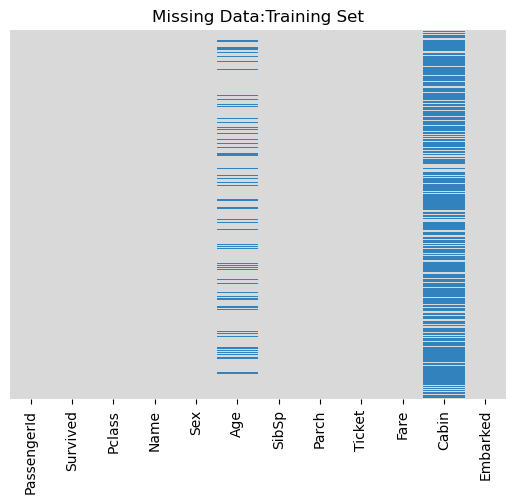

In [6]:
# HEATMAP
sns.heatmap(df.isnull(),yticklabels = False,cbar= False,cmap='tab20c_r')
plt.title('Missing Data:Training Set')
plt.show()

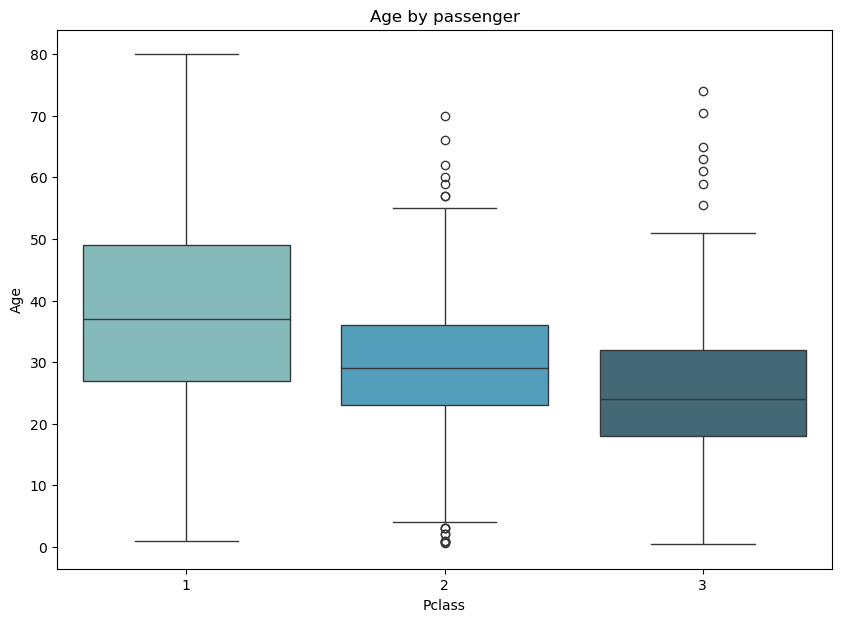

In [7]:
plt.figure(figsize=(10,7))
sns.boxplot(x='Pclass',y='Age',data = df,palette='GnBu_d').set_title('Age by passenger')
plt.show()

In [8]:
# Imputation Function
def impute(cols):
    Age=cols[0]
    Pclass= cols[1]

    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass ==2:
            return 29
        else:
            return 24
    else:
        return Age

In [9]:
df['Age']=df[['Age','Pclass']].apply(impute,axis=1)

In [10]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    24.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The cabin have too many missing value to do anything useful with so it would be best to remove it from data frame altogetther

In [12]:
df.drop('Cabin',axis = 1 , inplace = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# since there is only one missing value in embark that observation can just be removed

In [14]:
df.dropna(inplace = True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


*name  and ticket can be remove from the data set  as these feature donot provide additional information about a passenger liklihood of survival*

*The remeining  non nul value objects Sex Embarked will need tobe specified as categories  for  better  analysis result downstream*

In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [18]:
# Remove unncecessary columns
df.drop(['Name','Ticket','PassengerId'],axis = 1, inplace = True)

#  Convert objects to category data type
cat_col = ['Sex','Embarked']

for colname in cat_col:
    df[colname] = df[colname].astype('category')
    

In [19]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [20]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,24.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


# Numeric Feature

In [21]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.019314,0.524184,0.382452,32.096681
std,0.486260,0.834700,13.209814,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,36.500000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# GETTING MODEL READY
Now that we explore  the data it is time to get this feature model-ready categorial feature will need to be
converted into  dummy variable otherwise a machine learning algorithm will not be able to take those faetrure
as inputs

In [22]:
# shape of train data
df.shape

(889, 8)

In [23]:
# identify categorical feature
df.select_dtypes(['category']).columns

Index(['Sex', 'Embarked'], dtype='object')

In [24]:
# convert categorical variable into 'dummy'or indicator variables
sex=pd.get_dummies(df['Sex'],drop_first = True) # drop first prevents multi-collinearity
embarked = pd.get_dummies(df['Embarked'],drop_first = True)

In [25]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [26]:
df = pd.concat([df,sex,embarked],axis = 1)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,0,3,male,22.0,1,0,7.2500,S,True,False,True
1,1,1,female,38.0,1,0,71.2833,C,False,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,True,False,True


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  889 non-null    int64   
 1   Pclass    889 non-null    int64   
 2   Sex       889 non-null    category
 3   Age       889 non-null    float64 
 4   SibSp     889 non-null    int64   
 5   Parch     889 non-null    int64   
 6   Fare      889 non-null    float64 
 7   Embarked  889 non-null    category
 8   male      889 non-null    bool    
 9   Q         889 non-null    bool    
 10  S         889 non-null    bool    
dtypes: bool(3), category(2), float64(2), int64(4)
memory usage: 53.2 KB


In [28]:
# Drop unecessary columns
df.drop(['Sex','Embarked'],  axis = 1,inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Age       889 non-null    float64
 3   SibSp     889 non-null    int64  
 4   Parch     889 non-null    int64  
 5   Fare      889 non-null    float64
 6   male      889 non-null    bool   
 7   Q         889 non-null    bool   
 8   S         889 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 51.2 KB


In [31]:
# Shape  of  full data
print('full_data',df.shape)

full_data (889, 9)


In [32]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# MACHINE LEARNING 

Next i will feed this feature into various classification algorithm  to determine the best performance using a simple
framework Split,Fit,predict,Score it

# Target variable Spliting

we will split the full data set into input and target variable

input is also called Feature Variabloe output referes as Target variable

In [33]:
# split data to be use in model
# create matrix  of a feature
x= df.drop('Survived',axis = 1) # we place all data accept target data in x or input data and in y we place output data  only , target data nothing else

# create target variable 
y = df['Survived']

In [34]:
x.shape # it represent the feature / input  data

(889, 8)

In [35]:
y # y represent the target data
y.shape

(889,)

# pre_process = preprocessing.StandardScaler().fit(x)

This line fits the StandardScaler to the data x.

Fitting means that the scaler calculates the mean and standard deviation of each feature in x. This is done to prepare the scaler for later transformation.

Mean and Standard Deviation are used to scale the data so that each feature has a mean of 0 and a standard deviation of 1.

x_transform = pre_process.fit_transform(x)

This line is performing two actions in one:

Fit: It calculates the mean and standard deviation of x (again, just like the previous line).


Transform: It applies the scaling. Each value in x is adjusted so that the data is centered around 0 and scaled to have a standard deviation of 1.




Formula for scaling:

![image.png](attachment:68349f50-aadf-41da-847c-f869a8615335.png)

Where:


x = original data value


μ = mean of the feature


σ = standard deviation of the feature


z = transformed value





Why is this done?
Standardization (scaling) is done to ensure that features with larger values do not dominate over features with smaller values. Many machine learning algorithms (like linear regression, SVMs, and k-NN) are sensitive to the scale of the input data. Features with larger ranges can unfairly influence the model.
For example:


One feature may have a range of 0 to  1000, while another has a range of 0 to 1.

If you don't scale them, the feature with the larger range will dominate the model's learning process.

By applying StandardScaler, you transform each feature to have:

Mean = 0

Standard deviation = 1

This ensures that all features contribute equally to the model.

**In summary:**

fit(): Calculates the mean and standard deviation of each feature.

transform(): Applies the scaling to the features.

fit_transform(): Does both in one step calculating statistics and scaling the data.

This scaling is particularly useful for distance based models or algorithms that assume the data is normally distributed.

In [39]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [40]:
x_transform

array([[ 0.82520863, -0.53167023,  0.43135024, ...,  0.73534203,
        -0.30794088,  0.61679395],
       [-1.57221121,  0.68023223,  0.43135024, ..., -1.35991138,
        -0.30794088, -1.62128697],
       [ 0.82520863, -0.22869462, -0.47519908, ..., -1.35991138,
        -0.30794088,  0.61679395],
       ...,
       [ 0.82520863, -0.38018243,  0.43135024, ..., -1.35991138,
        -0.30794088,  0.61679395],
       [-1.57221121, -0.22869462, -0.47519908, ...,  0.73534203,
        -0.30794088, -1.62128697],
       [ 0.82520863,  0.22576881, -0.47519908, ...,  0.73534203,
         3.24737656, -1.62128697]], shape=(889, 8))

Scaling ka matlab hai standardization (z-score normalization) jisme values ko mean = 0 aur standard deviation = 1 ke hisaab se adjust kiya jata hai.

Is process mein, agar original values ka range 0 to 1 tha, toh scaled values ab negative aur positive range mein aati hain. Yeh values mean ke around centered hoti hain aur unka standard deviation 1 hota hai

In [41]:
# use x and y variable to splitr the training data into train and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size = .20,random_state = 101)


In [42]:
x_train.shape
x_train

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
307,1,17.0,1,0,108.9000,False,False,False
229,3,24.0,3,1,25.4667,False,False,True
82,3,24.0,0,0,7.7875,False,True,False
353,3,25.0,1,0,17.8000,True,False,True
707,1,42.0,0,0,26.2875,True,False,True
...,...,...,...,...,...,...,...,...
576,2,34.0,0,0,13.0000,False,False,True
840,3,20.0,0,0,7.9250,True,False,True
338,3,45.0,0,0,8.0500,True,False,True
524,3,24.0,0,0,7.2292,True,False,False


In [38]:
y_train.shape
y_train

307    1
229    0
82     1
353    0
707    1
      ..
576    1
840    0
338    1
524    0
865    1
Name: Survived, Length: 711, dtype: int64

# **1. LOGISTIC REGRESSION**

## **Model Training**

In [43]:
# Import model
from sklearn.linear_model import LogisticRegression

print('Logistic Regression')
# Create instance of model
log_reg = LogisticRegression()

# Pass training data into model
log_reg.fit(x_train, y_train)

Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## **Model Evaluation**
**Logistic regression**

In [44]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_log_reg = log_reg.predict(x_test)
# Score It

print('Logistic Regression')
# Accuracy
print('--'*30)
log_reg_accuracy = round(accuracy_score(y_test, y_pred_log_reg) * 100,2)
print('Accuracy', log_reg_accuracy,'%')

Logistic Regression
------------------------------------------------------------
Accuracy 82.02 %


In [45]:
print(y_test, y_pred_log_reg)

511    0
613    0
615    1
337    1
718    0
      ..
155    0
450    0
756    0
187    1
180    0
Name: Survived, Length: 178, dtype: int64 [0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]


In [46]:
# Combine y_test and y_pred_log_reg into a DataFrame
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_log_reg})

# Display the first few rows
comparison_df

,Actual,Predicted
511,0,0
613,0,0
615,1,1
337,1,1
718,0,0
...,...,...
155,0,0
450,0,0
756,0,0
187,1,0
